In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from scipy.io import wavfile
from scipy import signal

try:
    import sounddevice as sd
except Exception:
    sd = None

try:
    from pydub import AudioSegment
except Exception:
    AudioSegment = None

Книга

http://www.dspguide.com/about.htm

Образцы звуков

https://freewavesamples.com/

Документация в помощь

https://www.kaggle.com/code/ilyamich/mfcc-implementation-and-tutorial

https://prosound.ixbt.com/education/spektr-analys.shtml

https://opensource.com/article/19/9/audio-processing-machine-learning-python


In [8]:
# Скачиваю файлы звуков в Colab
from google.colab import files
uploaded = files.upload()

Saving Ensoniq-SQ-1-ClassicGuitar-C3.wav to Ensoniq-SQ-1-ClassicGuitar-C3 (1).wav
Saving Casio-CTK-611-Melodic-Tom-C3.wav to Casio-CTK-611-Melodic-Tom-C3 (1).wav


# Упражнения

1. Запишите два разных звука
1. Вычислить их спектральные характеристики (спектр, MFCC, GFCC)
1. Построение спектрограммы
1. Проанализируйте их сходства и различия

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display
from scipy.fft import rfft, rfftfreq
from scipy.spatial.distance import cosine, cdist
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

try:
    from spafe.features.gfcc import gfcc as spafe_gfcc
except Exception:
    spafe_gfcc = None

try:
    import seaborn as sns
except Exception:
    sns = None

RANDOM_STATE = 123
np.random.seed(RANDOM_STATE)

In [10]:
# 2 исходных звука скачанных выше + генерация дополнительных примеров
sound_1 = "Ensoniq-SQ-1-ClassicGuitar-C3.wav"
sound_2 = "Casio-CTK-611-Melodic-Tom-C3.wav"

sr = 22050
y1, _ = librosa.load(sound_1, sr=sr, mono=True)
y2, _ = librosa.load(sound_2, sr=sr, mono=True)

print(f"Источник 1: {sound_1}, отсчетов={len(y1)}, sr={sr}")
print(f"Источник 2: {sound_2}, отсчетов={len(y2)}, sr={sr}")


def normalize_audio(y):
    y = np.asarray(y, dtype=np.float32)
    denom = np.max(np.abs(y)) + 1e-8
    return y / denom


def make_segments(y, sr, clip_sec=1.2, step_sec=0.45, max_segments=6):
    n = int(clip_sec * sr)
    step = int(step_sec * sr)
    y = normalize_audio(y)
    segments = []
    for start in range(0, max(1, len(y) - n + 1), max(1, step)):
        seg = y[start : start + n]
        if len(seg) == n:
            segments.append(seg)
        if len(segments) >= max_segments:
            break
    if not segments:
        segments = [normalize_audio(y[:n])]
    return segments


def add_noise(y, noise_level=0.012):
    noise = np.random.normal(0.0, noise_level, size=len(y))
    return normalize_audio(y + noise)


records = []
for source_name, y in [("guitar", y1), ("violin", y2)]:
    segments = make_segments(y, sr, clip_sec=1.2, step_sec=0.45, max_segments=6)
    for i, seg in enumerate(segments):
        records.append(
            {
                "clip_id": f"{source_name}_clean_{i}",
                "source": source_name,
                "variant": "clean",
                "signal": seg,
            }
        )
        records.append(
            {
                "clip_id": f"{source_name}_noisy_{i}",
                "source": source_name,
                "variant": "noisy",
                "signal": add_noise(seg, noise_level=0.012),
            }
        )

print(f"Сформировано аудио-фрагментов: {len(records)}")
print(pd.DataFrame(records)[["clip_id", "source", "variant"]].head(8))


Источник 1: Ensoniq-SQ-1-ClassicGuitar-C3.wav, отсчетов=73027, sr=22050
Источник 2: Casio-CTK-611-Melodic-Tom-C3.wav, отсчетов=6166, sr=22050
Сформировано аудио-фрагментов: 12
          clip_id  source variant
0  guitar_clean_0  guitar   clean
1  guitar_noisy_0  guitar   noisy
2  guitar_clean_1  guitar   clean
3  guitar_noisy_1  guitar   noisy
4  guitar_clean_2  guitar   clean
5  guitar_noisy_2  guitar   noisy
6  guitar_clean_3  guitar   clean
7  guitar_noisy_3  guitar   noisy


In [11]:
# Вспомогательные функции: сигнал, спектр, спектрограмма, MFCC, GFCC, статистики
def magnitude_spectrum(y, sr):
    y = np.asarray(y, dtype=float)
    y = y - np.mean(y)
    n = len(y)
    spec = np.abs(rfft(y))
    freq = rfftfreq(n, 1 / sr)
    return freq, spec


def compute_features(y, sr, n_mfcc=13, n_gfcc=13):
    S = np.abs(librosa.stft(y, n_fft=1024, hop_length=256)) ** 2
    S_db = librosa.power_to_db(S, ref=np.max)
    mfcc_feat = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)

    if spafe_gfcc is not None:
        gfcc_feat = spafe_gfcc(y, fs=sr, num_ceps=n_gfcc).T
    else:
        # Fallback, если spafe недоступен: используем Mel-банки как замену.
        mel_fb = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_gfcc)
        gfcc_feat = librosa.power_to_db(mel_fb + 1e-8)

    centroid = float(librosa.feature.spectral_centroid(y=y, sr=sr).mean())
    rolloff = float(librosa.feature.spectral_rolloff(y=y, sr=sr).mean())
    bandwidth = float(librosa.feature.spectral_bandwidth(y=y, sr=sr).mean())
    zcr = float(librosa.feature.zero_crossing_rate(y=y).mean())
    rms = float(librosa.feature.rms(y=y).mean())

    return {
        "S_db": S_db,
        "mfcc": mfcc_feat,
        "gfcc": gfcc_feat,
        "centroid": centroid,
        "rolloff": rolloff,
        "bandwidth": bandwidth,
        "zcr": zcr,
        "rms": rms,
    }


def plot_waveform(y, sr, title):
    time = np.arange(len(y)) / sr
    plt.figure(figsize=(10.8, 2.6))
    plt.plot(time, y)
    plt.title(title)
    plt.xlabel("Время, с")
    plt.ylabel("Амплитуда")
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


def plot_spectrum(freq, spec, title):
    plt.figure(figsize=(10.8, 2.6))
    plt.plot(freq, spec)
    plt.xlim(0, sr / 2)
    plt.title(title)
    plt.xlabel("Частота, Гц")
    plt.ylabel("Модуль")
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


def plot_feature_map(feature, title, sr, hop=256, mode="coef"):
    plt.figure(figsize=(10.8, 2.8))
    if mode == "spec":
        librosa.display.specshow(feature, sr=sr, hop_length=hop, x_axis="time", y_axis="hz")
    else:
        plt.imshow(feature, aspect="auto", origin="lower", interpolation="nearest")
        plt.xlabel("Кадр")
        plt.ylabel("Индекс коэффициента")
    plt.title(title)
    plt.colorbar()
    plt.tight_layout()
    plt.show()


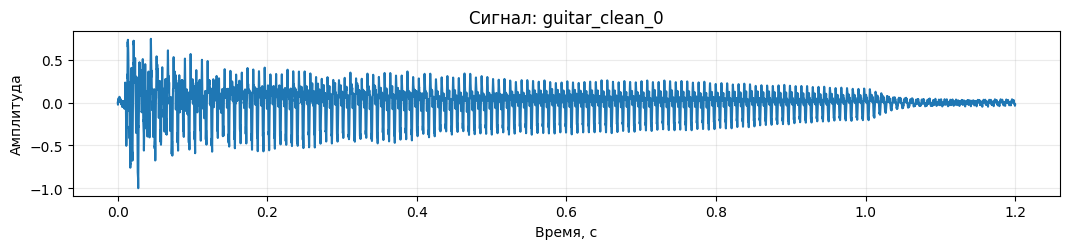

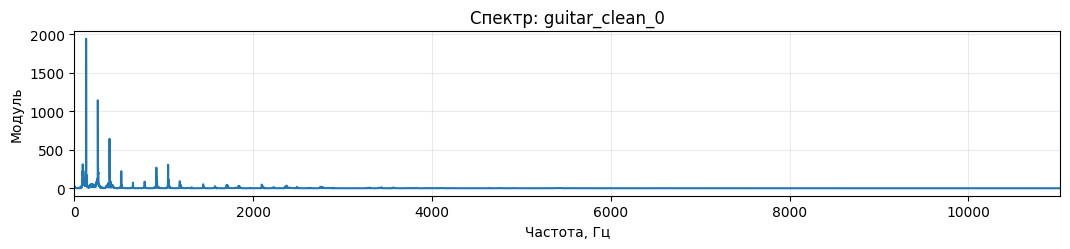

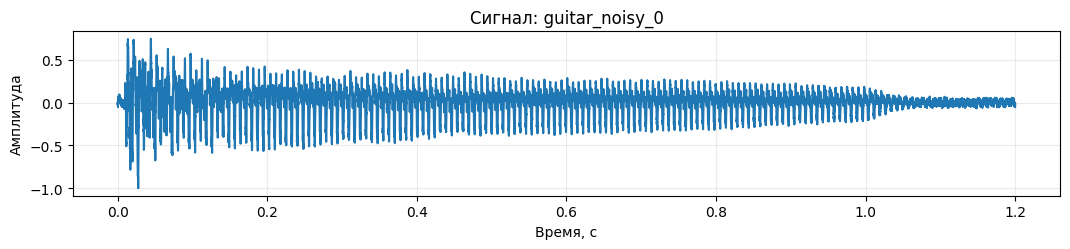

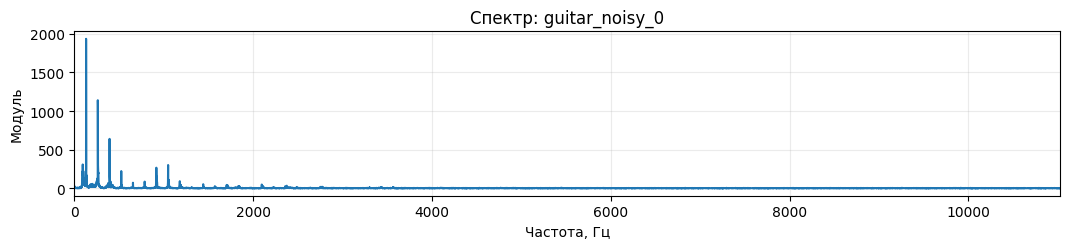

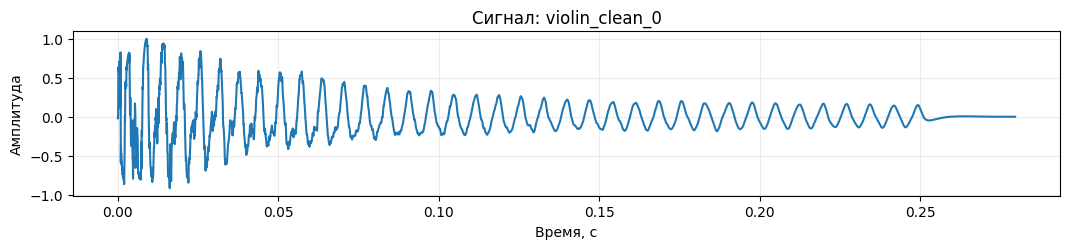

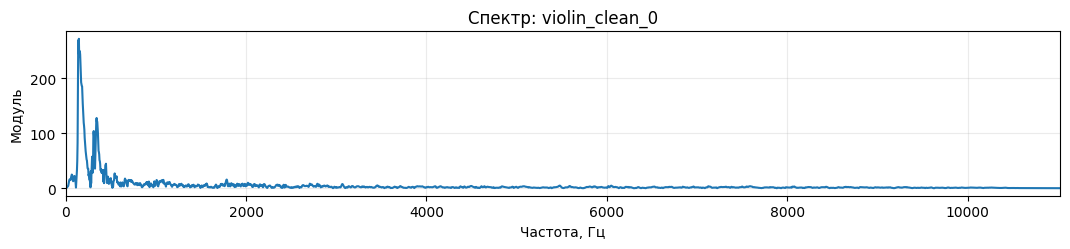

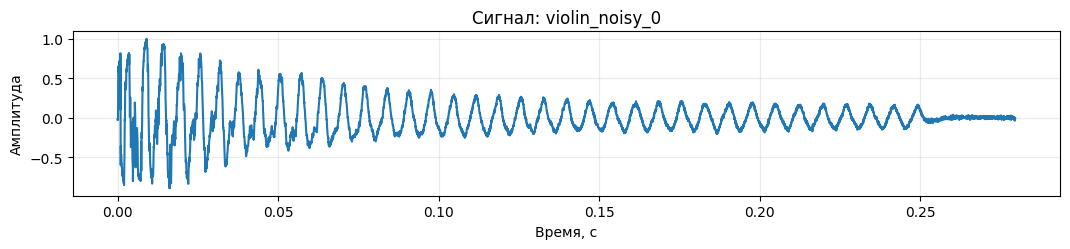

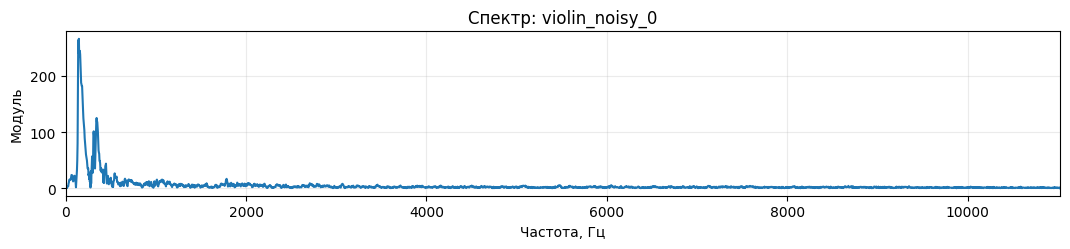

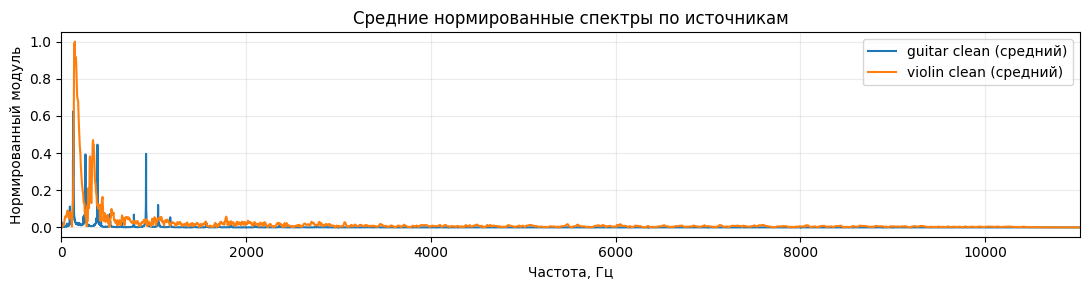

In [12]:
# 1) Волны и спектры: показываем больше примеров из разных источников/вариантов
example_ids = [
    ("guitar", "clean", 0),
    ("guitar", "noisy", 0),
    ("violin", "clean", 0),
    ("violin", "noisy", 0),
]

for source_name, variant, idx in example_ids:
    rec = next(r for r in records if r["source"] == source_name and r["variant"] == variant and r["clip_id"].endswith(f"_{idx}"))
    y = rec["signal"]
    plot_waveform(y, sr, f"Сигнал: {rec['clip_id']}")
    f, spec = magnitude_spectrum(y, sr)
    plot_spectrum(f, spec, f"Спектр: {rec['clip_id']}")

# Усредненный спектр по классам (clean-варианты), чтобы сравнить общую форму.
def average_spectrum(records_subset):
    specs = []
    freq_ref = None
    for r in records_subset:
        f, s = magnitude_spectrum(r["signal"], sr)
        if freq_ref is None:
            freq_ref = f
        specs.append(s / (np.max(s) + 1e-8))
    return freq_ref, np.mean(np.vstack(specs), axis=0)

guitar_clean = [r for r in records if r["source"] == "guitar" and r["variant"] == "clean"]
violin_clean = [r for r in records if r["source"] == "violin" and r["variant"] == "clean"]

fg, sg = average_spectrum(guitar_clean)
fv, sv = average_spectrum(violin_clean)

plt.figure(figsize=(11, 3))
plt.plot(fg, sg, label="guitar clean (средний)")
plt.plot(fv, sv, label="violin clean (средний)")
plt.xlim(0, sr / 2)
plt.title("Средние нормированные спектры по источникам")
plt.xlabel("Частота, Гц")
plt.ylabel("Нормированный модуль")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()


,clip_id,source,variant,centroid,rolloff,bandwidth,zcr,rms
0,guitar_clean_0,guitar,clean,607.436395,1150.784067,849.829102,0.034377,0.156562
1,guitar_noisy_0,guitar,noisy,2498.846449,6277.549861,3069.385803,0.064059,0.156739
2,guitar_clean_1,guitar,clean,645.404383,1046.016752,995.472292,0.039654,0.074445
3,guitar_noisy_1,guitar,noisy,3735.973743,8019.668814,3303.021859,0.184852,0.194500
4,guitar_clean_2,guitar,clean,864.649415,1242.507230,1441.274324,0.041870,0.020156
5,guitar_noisy_2,guitar,noisy,4845.321082,9003.363507,3329.921273,0.338426,0.097539
6,guitar_clean_3,guitar,clean,1321.083261,2575.495324,2102.975736,0.044105,0.003960
7,guitar_noisy_3,guitar,noisy,5348.290700,9293.440599,3240.893459,0.450552,0.218541
8,guitar_clean_4,guitar,clean,2048.942962,4864.640456,2717.944629,0.055974,0.001384
9,guitar_noisy_4,guitar,noisy,5514.597416,9372.740760,3198.403524,0.481032,0.241432


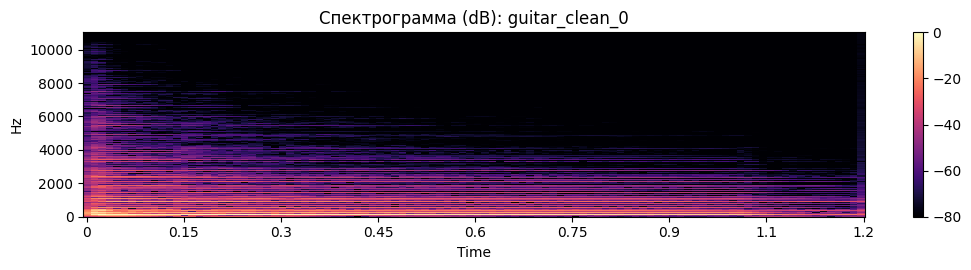

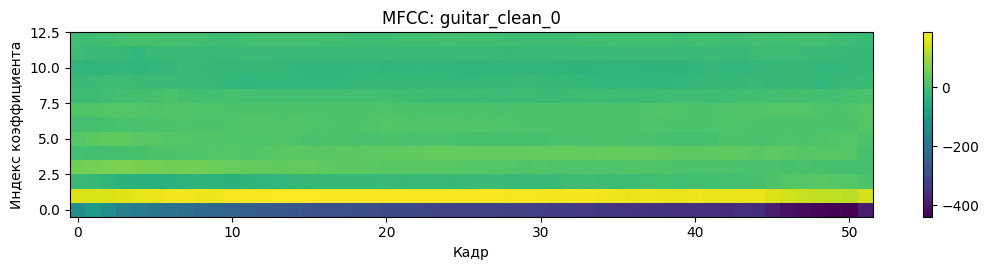

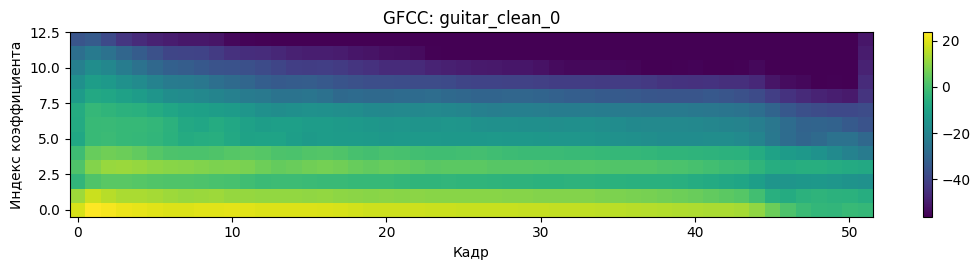

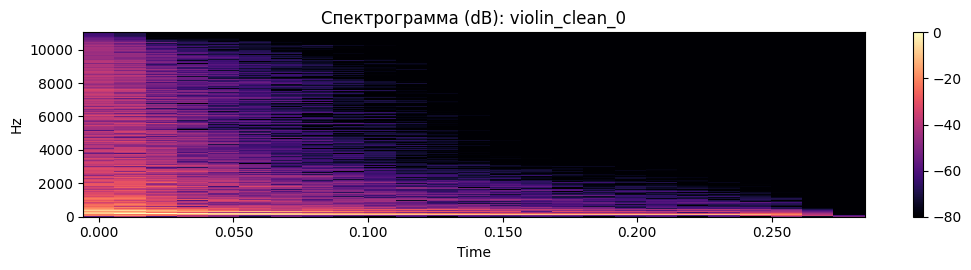

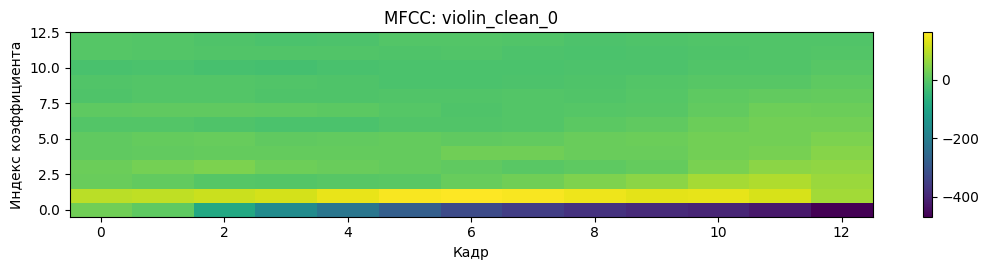

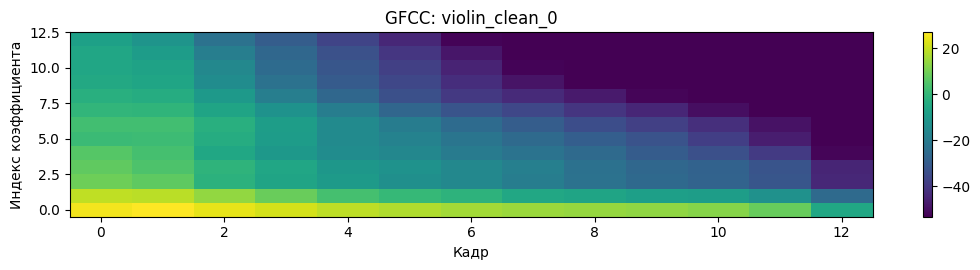

In [13]:
# 2) MFCC/GFCC и 3) спектрограммы для всех записей + визуализация представителей
feature_rows = []

for r in records:
    feats = compute_features(r["signal"], sr)
    r["features"] = feats

    mfcc_mean = feats["mfcc"].mean(axis=1)
    mfcc_std = feats["mfcc"].std(axis=1)
    gfcc_mean = feats["gfcc"].mean(axis=1)
    gfcc_std = feats["gfcc"].std(axis=1)

    emb = np.concatenate([mfcc_mean, mfcc_std, gfcc_mean, gfcc_std])
    r["embedding"] = emb

    feature_rows.append(
        {
            "clip_id": r["clip_id"],
            "source": r["source"],
            "variant": r["variant"],
            "centroid": feats["centroid"],
            "rolloff": feats["rolloff"],
            "bandwidth": feats["bandwidth"],
            "zcr": feats["zcr"],
            "rms": feats["rms"],
        }
    )

features_df = pd.DataFrame(feature_rows)
display(features_df.head(10))

for source_name in ["guitar", "violin"]:
    rec = next(r for r in records if r["source"] == source_name and r["variant"] == "clean")
    feats = rec["features"]
    plot_feature_map(feats["S_db"], f"Спектрограмма (dB): {rec['clip_id']}", sr=sr, mode="spec")
    plot_feature_map(feats["mfcc"], f"MFCC: {rec['clip_id']}", sr=sr, mode="coef")
    plot_feature_map(feats["gfcc"], f"GFCC: {rec['clip_id']}", sr=sr, mode="coef")


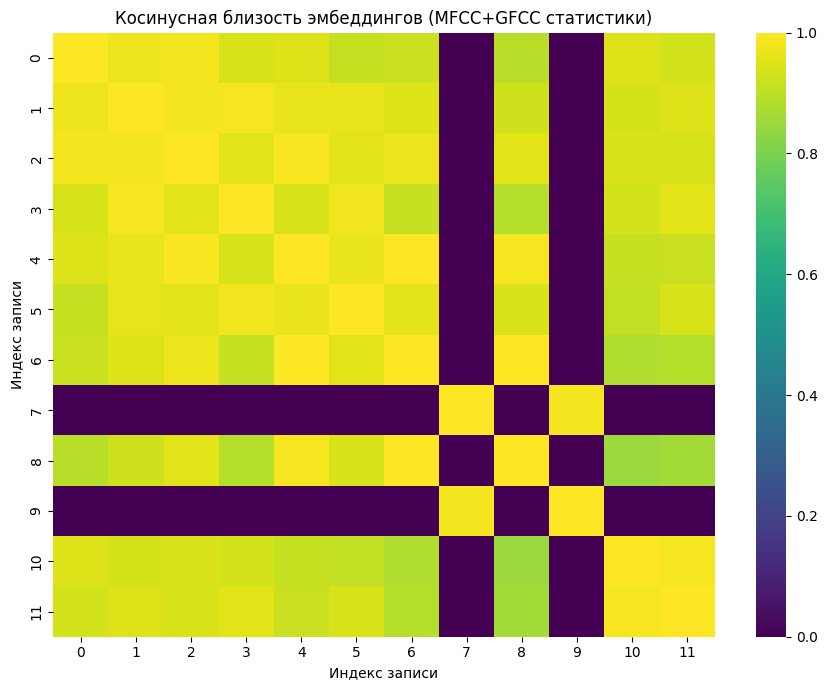

centroid           rolloff          bandwidth           zcr  \
                   mean      std     mean      std      mean     std  mean   
source variant                                                               
guitar clean    1097.50   602.91  2175.89  1626.94   1621.50  783.24  0.04   
       noisy    4388.61  1264.37  8393.35  1299.78   3228.33  102.73  0.30   
violin clean     775.00      NaN  1578.55      NaN   1251.31     NaN  0.01   
       noisy    2863.98      NaN  7140.74      NaN   3271.01     NaN  0.05   

                       rms        
                 std  mean   std  
source variant                    
guitar clean    0.01  0.05  0.07  
       noisy    0.18  0.18  0.06  
violin clean     NaN  0.19   NaN  
       noisy     NaN  0.19   NaN

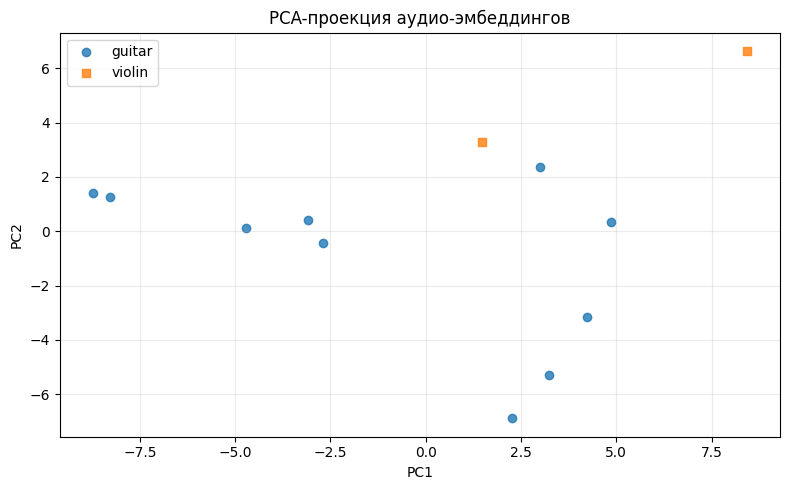

Средняя внутриклассовая косинусная близость: 0.3422
Средняя межклассовая косинусная близость:   0.6034


In [16]:
# 4) Подробный анализ сходств/различий: таблицы, матрица близости, PCA-проекция
emb_matrix = np.vstack([r["embedding"] for r in records])
clip_ids = [r["clip_id"] for r in records]
sources = [r["source"] for r in records]
variants = [r["variant"] for r in records]

# Косинусная близость между всеми парами записей.
sim_matrix = 1.0 - cdist(emb_matrix, emb_matrix, metric="cosine")

if sns is not None:
    plt.figure(figsize=(9, 7))
    sns.heatmap(sim_matrix, cmap="viridis", vmin=0.0, vmax=1.0)
    plt.title("Косинусная близость эмбеддингов (MFCC+GFCC статистики)")
    plt.xlabel("Индекс записи")
    plt.ylabel("Индекс записи")
    plt.tight_layout()
    plt.show()
else:
    plt.figure(figsize=(9, 7))
    plt.imshow(sim_matrix, aspect="auto", cmap="viridis", vmin=0.0, vmax=1.0)
    plt.title("Косинусная близость эмбеддингов (MFCC+GFCC статистики)")
    plt.xlabel("Индекс записи")
    plt.ylabel("Индекс записи")
    plt.colorbar()
    plt.tight_layout()
    plt.show()

# Сравнение внутриклассовой и межклассовой близости.
within_vals = []
between_vals = []
for i in range(len(records)):
    for j in range(i + 1, len(records)):
        if sources[i] == sources[j]:
            within_vals.append(sim_matrix[i, j])
        else:
            between_vals.append(sim_matrix[i, j])

within_mean = float(np.mean(within_vals))
between_mean = float(np.mean(between_vals))

# Статистика спектральных признаков по источникам.
group_stats = (
    features_df.groupby(["source", "variant"])[["centroid", "rolloff", "bandwidth", "zcr", "rms"]]
    .agg(["mean", "std"])
    .round(2)
)
display(group_stats)

# PCA в 2D по эмбеддингам для визуального сравнения.
X_scaled = StandardScaler().fit_transform(emb_matrix)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 5))
for source_name, marker in [("guitar", "o"), ("violin", "s")]:
    idx = [k for k, s in enumerate(sources) if s == source_name]
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], marker=marker, label=source_name, alpha=0.8)
plt.title("PCA-проекция аудио-эмбеддингов")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Средняя внутриклассовая косинусная близость: {within_mean:.4f}")
print(f"Средняя межклассовая косинусная близость:   {between_mean:.4f}")
